## Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from sklearn.preprocessing import StandardScaler
from skimage import feature, filters, exposure
from scipy import stats
import joblib
import json
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Configuration
SPLITS_PATH = '../data/splits'
FEATURES_PATH = '../data/features'
RESULTS_PATH = '../results'

# Create output directories
os.makedirs(FEATURES_PATH, exist_ok=True)

# Load data
X_train = np.load(f'{SPLITS_PATH}/X_train.npy')
y_train = np.load(f'{SPLITS_PATH}/y_train.npy')
X_val = np.load(f'{SPLITS_PATH}/X_val.npy')
y_val = np.load(f'{SPLITS_PATH}/y_val.npy')
X_test = np.load(f'{SPLITS_PATH}/X_test.npy')
y_test = np.load(f'{SPLITS_PATH}/y_test.npy')

print(f"✓ Data loaded")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✓ Data loaded
Train: (256, 360, 360, 3), Val: (64, 360, 360, 3), Test: (80, 360, 360, 3)


## Feature Extraction Base Class

In [2]:
class FeatureExtractor:
    """Base class for feature extraction methods"""
    
    def __init__(self, name: str):
        self.name = name
        self.features_train = None
        self.features_val = None
        self.features_test = None
        self.feature_names = None
        self.metadata = {
            'name': name,
            'n_features': 0,
            'extraction_time': 0,
        }
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """Extract features from images. To be overridden by subclasses."""
        raise NotImplementedError
    
    def fit_transform(self, X_train: np.ndarray, X_val: np.ndarray, 
                     X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Extract features from all datasets"""
        import time
        
        start = time.time()
        print(f"\nExtracting {self.name}...")
        
        self.features_train = self.extract(X_train)
        self.features_val = self.extract(X_val)
        self.features_test = self.extract(X_test)
        
        elapsed = time.time() - start
        self.metadata['extraction_time'] = elapsed
        self.metadata['n_features'] = self.features_train.shape[1]
        
        print(f"✓ {self.name}")
        print(f"  Train features: {self.features_train.shape}")
        print(f"  Val features: {self.features_val.shape}")
        print(f"  Test features: {self.features_test.shape}")
        print(f"  Time: {elapsed:.2f}s")
        
        return self.features_train, self.features_val, self.features_test
    
    def save_features(self, path: str):
        """Save extracted features"""
        np.save(f'{path}/{self.name}_train.npy', self.features_train)
        np.save(f'{path}/{self.name}_val.npy', self.features_val)
        np.save(f'{path}/{self.name}_test.npy', self.features_test)
    
    def get_metadata(self) -> dict:
        return self.metadata

## Method 1 - Raw Pixel Features

In [3]:
class RawPixelExtractor(FeatureExtractor):
    """Extract raw pixel values as features"""
    
    def __init__(self):
        super().__init__('raw_pixels')
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Flatten each image to 1D vector of pixel values
        Input: (N, H, W, C)
        Output: (N, H*W*C)
        """
        n_images = images.shape[0]
        h, w, c = images.shape[1:]
        
        features = images.reshape(n_images, -1)
        
        if self.feature_names is None:
            self.feature_names = [f'pixel_{i}' for i in range(features.shape[1])]
        
        return features

# Extract
raw_extractor = RawPixelExtractor()
raw_train, raw_val, raw_test = raw_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nRaw pixel statistics:")
print(f"  Min: {raw_train.min():.3f}")
print(f"  Max: {raw_train.max():.3f}")
print(f"  Mean: {raw_train.mean():.3f}")
print(f"  Std: {raw_train.std():.3f}")


Extracting raw_pixels...
✓ raw_pixels
  Train features: (256, 388800)
  Val features: (64, 388800)
  Test features: (80, 388800)
  Time: 0.16s

Raw pixel statistics:
  Min: 0.000
  Max: 0.004
  Mean: 0.002
  Std: 0.001


## Method 2 - Color Histogram Features

In [4]:
class ColorHistogramExtractor(FeatureExtractor):
    """Extract RGB color histograms"""
    
    def __init__(self, bins: int = 32):
        super().__init__(f'color_histogram_bins{bins}')
        self.bins = bins
        self.metadata['bins'] = bins
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract color histograms from each image
        Input: (N, H, W, C)
        Output: (N, bins*3)
        """
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            img = images[i]
            
            # Extract histogram for each channel
            hist_r = np.histogram(img[:, :, 0], bins=self.bins, range=(0, 1))[0]
            hist_g = np.histogram(img[:, :, 1], bins=self.bins, range=(0, 1))[0]
            hist_b = np.histogram(img[:, :, 2], bins=self.bins, range=(0, 1))[0]
            
            # Normalize histograms
            hist_r = hist_r / (hist_r.sum() + 1e-7)
            hist_g = hist_g / (hist_g.sum() + 1e-7)
            hist_b = hist_b / (hist_b.sum() + 1e-7)
            
            # Concatenate
            hist_features = np.concatenate([hist_r, hist_g, hist_b])
            features_list.append(hist_features)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = (
                [f'hist_r_{i}' for i in range(self.bins)] +
                [f'hist_g_{i}' for i in range(self.bins)] +
                [f'hist_b_{i}' for i in range(self.bins)]
            )
        
        return features

# Extract
hist_extractor = ColorHistogramExtractor(bins=32)
hist_train, hist_val, hist_test = hist_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nColor histogram statistics:")
print(f"  Min: {hist_train.min():.3f}")
print(f"  Max: {hist_train.max():.3f}")
print(f"  Mean: {hist_train.mean():.3f}")
print(f"  Std: {hist_train.std():.3f}")


Extracting color_histogram_bins32...
✓ color_histogram_bins32
  Train features: (256, 96)
  Val features: (64, 96)
  Test features: (80, 96)
  Time: 4.41s

Color histogram statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.031
  Std: 0.174


## Method 3 - Color Statistics Features

In [5]:
class ColorStatsExtractor(FeatureExtractor):
    """Extract color channel statistics"""
    
    def __init__(self):
        super().__init__('color_stats')
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract per-channel statistics
        For each channel: mean, std, min, max, median, skewness, kurtosis
        Input: (N, H, W, C)
        Output: (N, 7*3 = 21)
        """
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            img = images[i]
            stats_list = []
            
            for channel in range(3):
                channel_data = img[:, :, channel].flatten()
                
                stats_list.extend([
                    channel_data.mean(),
                    channel_data.std(),
                    channel_data.min(),
                    channel_data.max(),
                    np.median(channel_data),
                    stats.skew(channel_data),
                    stats.kurtosis(channel_data),
                ])
            
            features_list.append(stats_list)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            channel_names = ['R', 'G', 'B']
            stats_names = ['mean', 'std', 'min', 'max', 'median', 'skew', 'kurtosis']
            self.feature_names = [f'{ch}_{stat}' for ch in channel_names for stat in stats_names]
        
        return features

# Extract
color_stats_extractor = ColorStatsExtractor()
color_stats_train, color_stats_val, color_stats_test = color_stats_extractor.fit_transform(
    X_train, X_val, X_test
)

print(f"\nColor statistics shape: {color_stats_train.shape}")
print(f"  Min: {color_stats_train.min():.3f}")
print(f"  Max: {color_stats_train.max():.3f}")
print(f"  Mean: {color_stats_train.mean():.3f}")
print(f"  Std: {color_stats_train.std():.3f}")


Extracting color_stats...
✓ color_stats
  Train features: (256, 21)
  Val features: (64, 21)
  Test features: (80, 21)
  Time: 8.80s

Color statistics shape: (256, 21)
  Min: -1.554
  Max: 0.868
  Mean: -0.096
  Std: 0.386


## Method 4 - HSV Color Space Features

In [6]:
class HSVExtractor(FeatureExtractor):
    """Extract HSV color space histograms"""
    
    def __init__(self, bins: int = 16):
        super().__init__(f'hsv_histogram_bins{bins}')
        self.bins = bins
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Convert to HSV and extract histograms
        Input: (N, H, W, C) with values in [0, 1]
        Output: (N, bins*3)
        """
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            # Convert from RGB [0,1] to HSV
            img_hsv = cv2.cvtColor((images[i] * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
            img_hsv = img_hsv.astype(np.float32) / 255.0
            
            # Extract histograms
            hist_h = np.histogram(img_hsv[:, :, 0], bins=self.bins, range=(0, 1))[0]
            hist_s = np.histogram(img_hsv[:, :, 1], bins=self.bins, range=(0, 1))[0]
            hist_v = np.histogram(img_hsv[:, :, 2], bins=self.bins, range=(0, 1))[0]
            
            # Normalize
            hist_h = hist_h / (hist_h.sum() + 1e-7)
            hist_s = hist_s / (hist_s.sum() + 1e-7)
            hist_v = hist_v / (hist_v.sum() + 1e-7)
            
            features_list.append(np.concatenate([hist_h, hist_s, hist_v]))
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = (
                [f'hist_h_{i}' for i in range(self.bins)] +
                [f'hist_s_{i}' for i in range(self.bins)] +
                [f'hist_v_{i}' for i in range(self.bins)]
            )
        
        return features

# Extract
hsv_extractor = HSVExtractor(bins=16)
hsv_train, hsv_val, hsv_test = hsv_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nHSV histogram statistics:")
print(f"  Min: {hsv_train.min():.3f}")
print(f"  Max: {hsv_train.max():.3f}")
print(f"  Mean: {hsv_train.mean():.3f}")
print(f"  Std: {hsv_train.std():.3f}")


Extracting hsv_histogram_bins16...
✓ hsv_histogram_bins16
  Train features: (256, 48)
  Val features: (64, 48)
  Test features: (80, 48)
  Time: 2.68s

HSV histogram statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.062
  Std: 0.241


## Method 5 - Texture Features (LBP - Local Binary Patterns)

In [7]:
class LBPExtractor(FeatureExtractor):
    """Extract Local Binary Pattern (LBP) texture features"""
    
    def __init__(self, radius: int = 1, n_points: int = 8, bins: int = 59):
        super().__init__(f'lbp_r{radius}_p{n_points}_bins{bins}')
        self.radius = radius
        self.n_points = n_points
        self.bins = bins
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract LBP histograms from grayscale images
        Input: (N, H, W, C)
        Output: (N, bins)
        """
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            # Convert to grayscale
            img_gray = cv2.cvtColor((images[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            
            # Extract LBP
            lbp = feature.local_binary_pattern(
                img_gray, 
                P=self.n_points, 
                R=self.radius, 
                method='uniform'
            )
            
            # Create histogram
            hist, _ = np.histogram(lbp.ravel(), bins=self.bins, range=(0, self.bins))
            
            # Normalize
            hist = hist / (hist.sum() + 1e-7)
            features_list.append(hist)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = [f'lbp_{i}' for i in range(self.bins)]
        
        return features

# Extract
lbp_extractor = LBPExtractor(radius=1, n_points=8, bins=59)
lbp_train, lbp_val, lbp_test = lbp_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nLBP histogram statistics:")
print(f"  Min: {lbp_train.min():.3f}")
print(f"  Max: {lbp_train.max():.3f}")
print(f"  Mean: {lbp_train.mean():.3f}")
print(f"  Std: {lbp_train.std():.3f}")


Extracting lbp_r1_p8_bins59...
✓ lbp_r1_p8_bins59
  Train features: (256, 59)
  Val features: (64, 59)
  Test features: (80, 59)
  Time: 6.27s

LBP histogram statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.017
  Std: 0.129


## Method 6 - Edge Detection Features (Canny Edges)

In [8]:
class EdgeExtractor(FeatureExtractor):
    """Extract edge-based features using Canny edge detection"""
    
    def __init__(self, low_threshold: int = 50, high_threshold: int = 150):
        super().__init__(f'edge_features_t{low_threshold}_{high_threshold}')
        self.low_threshold = low_threshold
        self.high_threshold = high_threshold
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract edge statistics
        For each image:
        - Edge density (% of pixels that are edges)
        - Edge distribution per region (4 quadrants)
        - Edge orientation histogram
        
        Input: (N, H, W, C)
        Output: (N, 4 + 8) = (N, 12)
        """
        n_images = images.shape[0]
        features_list = []
        h, w = images.shape[1:3]
        
        for i in range(n_images):
            # Convert to grayscale
            img_gray = cv2.cvtColor((images[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            
            # Canny edge detection
            edges = cv2.Canny(img_gray, self.low_threshold, self.high_threshold)
            
            # Overall edge density
            edge_density = edges.sum() / (h * w)
            
            # Quadrant edge densities
            h_half, w_half = h // 2, w // 2
            quadrants = [
                edges[:h_half, :w_half],
                edges[:h_half, w_half:],
                edges[h_half:, :w_half],
                edges[h_half:, w_half:],
            ]
            quadrant_densities = [q.sum() / q.size for q in quadrants]
            
            # Edge orientation (Sobel derivatives)
            sobelx = cv2.Sobel(img_gray, cv2.CV_32F, 1, 0, ksize=3)
            sobely = cv2.Sobel(img_gray, cv2.CV_32F, 0, 1, ksize=3)
            
            # Angle histogram
            angles = np.arctan2(sobely, sobelx)
            angle_hist, _ = np.histogram(angles.ravel(), bins=8, range=(-np.pi, np.pi))
            angle_hist = angle_hist / (angle_hist.sum() + 1e-7)
            
            # Combine features
            feat = [edge_density] + quadrant_densities + list(angle_hist)
            features_list.append(feat)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = (
                ['edge_density'] +
                ['quadrant_0', 'quadrant_1', 'quadrant_2', 'quadrant_3'] +
                [f'angle_{i}' for i in range(8)]
            )
        
        return features

# Extract
edge_extractor = EdgeExtractor(low_threshold=50, high_threshold=150)
edge_train, edge_val, edge_test = edge_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nEdge features statistics:")
print(f"  Min: {edge_train.min():.3f}")
print(f"  Max: {edge_train.max():.3f}")
print(f"  Mean: {edge_train.mean():.3f}")
print(f"  Std: {edge_train.std():.3f}")


Extracting edge_features_t50_150...
✓ edge_features_t50_150
  Train features: (256, 13)
  Val features: (64, 13)
  Test features: (80, 13)
  Time: 1.56s

Edge features statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.077
  Std: 0.265


## Method 7 - HOG (Histogram of Oriented Gradients)

In [9]:
class HOGExtractor(FeatureExtractor):
    """Extract Histogram of Oriented Gradients features"""
    
    def __init__(self, orientations: int = 9, pixels_per_cell: int = 16, 
                 cells_per_block: int = 2):
        super().__init__(f'hog_o{orientations}_ppc{pixels_per_cell}_cpb{cells_per_block}')
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract HOG features
        Input: (N, H, W, C)
        Output: (N, n_hog_features)
        """
        from skimage.feature import hog
        
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            # Convert to grayscale
            img_gray = cv2.cvtColor((images[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            
            # Extract HOG
            hog_features = hog(
                img_gray,
                orientations=self.orientations,
                pixels_per_cell=(self.pixels_per_cell, self.pixels_per_cell),
                cells_per_block=(self.cells_per_block, self.cells_per_block),
                visualize=False,
                channel_axis=None
            )
            
            features_list.append(hog_features)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = [f'hog_{i}' for i in range(features.shape[1])]
        
        return features

# Extract
hog_extractor = HOGExtractor(orientations=9, pixels_per_cell=16, cells_per_block=2)
hog_train, hog_val, hog_test = hog_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nHOG features statistics:")
print(f"  Min: {hog_train.min():.3f}")
print(f"  Max: {hog_train.max():.3f}")
print(f"  Mean: {hog_train.mean():.3f}")
print(f"  Std: {hog_train.std():.3f}")


Extracting hog_o9_ppc16_cpb2...
✓ hog_o9_ppc16_cpb2
  Train features: (256, 15876)
  Val features: (64, 15876)
  Test features: (80, 15876)
  Time: 5.03s

HOG features statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.006
  Std: 0.052


## Method 8 - Gabor Filter Features

In [10]:
class GaborExtractor(FeatureExtractor):
    """Extract Gabor filter responses"""
    
    def __init__(self, scales: int = 5, orientations: int = 8, kernel_size: int = 21):
        super().__init__(f'gabor_s{scales}_o{orientations}_ks{kernel_size}')
        self.scales = scales
        self.orientations = orientations
        self.kernel_size = kernel_size
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Extract Gabor filter responses (texture features)
        Input: (N, H, W, C)
        Output: (N, scales*orientations*4) where 4 = [mean, std, min, max]
        """
        n_images = images.shape[0]
        features_list = []
        
        for i in range(n_images):
            # Convert to grayscale
            img_gray = cv2.cvtColor((images[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            img_gray = img_gray.astype(np.float32)
            
            gabor_features = []
            
            for scale in range(self.scales):
                sigma = 2 ** scale / np.sqrt(2)
                lambd = 10 / (2 ** scale)
                
                for orientation in range(self.orientations):
                    theta = orientation * np.pi / self.orientations
                    
                    # Create Gabor kernel
                    kernel = cv2.getGaborKernel(
                        (self.kernel_size, self.kernel_size),
                        sigma,
                        theta,
                        lambd,
                        0.5,
                        0
                    )
                    
                    # Apply filter
                    response = cv2.filter2D(img_gray, cv2.CV_32F, kernel)
                    
                    # Extract statistics
                    gabor_features.extend([
                        response.mean(),
                        response.std(),
                        response.min(),
                        response.max(),
                    ])
            
            features_list.append(gabor_features)
        
        features = np.array(features_list)
        
        if self.feature_names is None:
            self.feature_names = [f'gabor_{i}' for i in range(features.shape[1])]
        
        return features

# Extract
gabor_extractor = GaborExtractor(scales=3, orientations=6, kernel_size=21)
gabor_train, gabor_val, gabor_test = gabor_extractor.fit_transform(X_train, X_val, X_test)

print(f"\nGabor features statistics:")
print(f"  Min: {gabor_train.min():.3f}")
print(f"  Max: {gabor_train.max():.3f}")
print(f"  Mean: {gabor_train.mean():.3f}")
print(f"  Std: {gabor_train.std():.3f}")


Extracting gabor_s3_o6_ks21...
✓ gabor_s3_o6_ks21
  Train features: (256, 72)
  Val features: (64, 72)
  Test features: (80, 72)
  Time: 33.57s

Gabor features statistics:
  Min: -8.874
  Max: 10.308
  Mean: 0.945
  Std: 2.859


## Method 9 - Combined Hybrid Features

In [11]:
class HybridExtractor(FeatureExtractor):
    """Combine multiple feature extraction methods"""
    
    def __init__(self):
        super().__init__('hybrid_features')
    
    def extract(self, images: np.ndarray) -> np.ndarray:
        """
        Combine: color stats, color histogram, LBP, edge features
        """
        extractors = [
            ColorStatsExtractor(),
            ColorHistogramExtractor(bins=16),
            LBPExtractor(radius=1, n_points=8, bins=59),
            EdgeExtractor(low_threshold=50, high_threshold=150),
        ]
        
        # Note: we'll use instances created earlier instead
        # For now, just combine the already extracted features
        pass

# Combine all feature sets
def create_hybrid_features(feat1, feat2, feat3, feat4, feat5):
    """Combine multiple feature sets"""
    return np.hstack([feat1, feat2, feat3, feat4, feat5])

hybrid_train = create_hybrid_features(
    color_stats_train, hist_train, lbp_train, edge_train, hog_train
)
hybrid_val = create_hybrid_features(
    color_stats_val, hist_val, lbp_val, edge_val, hog_val
)
hybrid_test = create_hybrid_features(
    color_stats_test, hist_test, lbp_test, edge_test, hog_test
)

print(f"\nHybrid features shape: {hybrid_train.shape}")
print(f"  Min: {hybrid_train.min():.3f}")
print(f"  Max: {hybrid_train.max():.3f}")
print(f"  Mean: {hybrid_train.mean():.3f}")
print(f"  Std: {hybrid_train.std():.3f}")


Hybrid features shape: (256, 16065)
  Min: -1.554
  Max: 1.000
  Mean: 0.006
  Std: 0.056


## Visualize Feature Distributions

Processing Raw Pixels... Shape: (256, 388800)
  ✓ Explained variance: 0.274
Processing Color Stats... Shape: (256, 21)
  ✓ Explained variance: 0.741
Processing Color Histogram... Shape: (256, 96)
  ✓ Explained variance: 1.000
  ⚠️ Warning: Color Histogram has insufficient variance for histogram
Processing HSV Histogram... Shape: (256, 48)
  ✓ Explained variance: 0.858
Processing LBP Texture... Shape: (256, 59)
  ✓ Explained variance: 0.969
Processing Edge Features... Shape: (256, 13)
  ✓ Explained variance: 0.869
Processing HOG... Shape: (256, 15876)
  ✓ Explained variance: 0.159
Processing Gabor... Shape: (256, 72)
  ✓ Explained variance: 0.810
Processing Hybrid... Shape: (256, 16065)
  ✓ Explained variance: 0.159


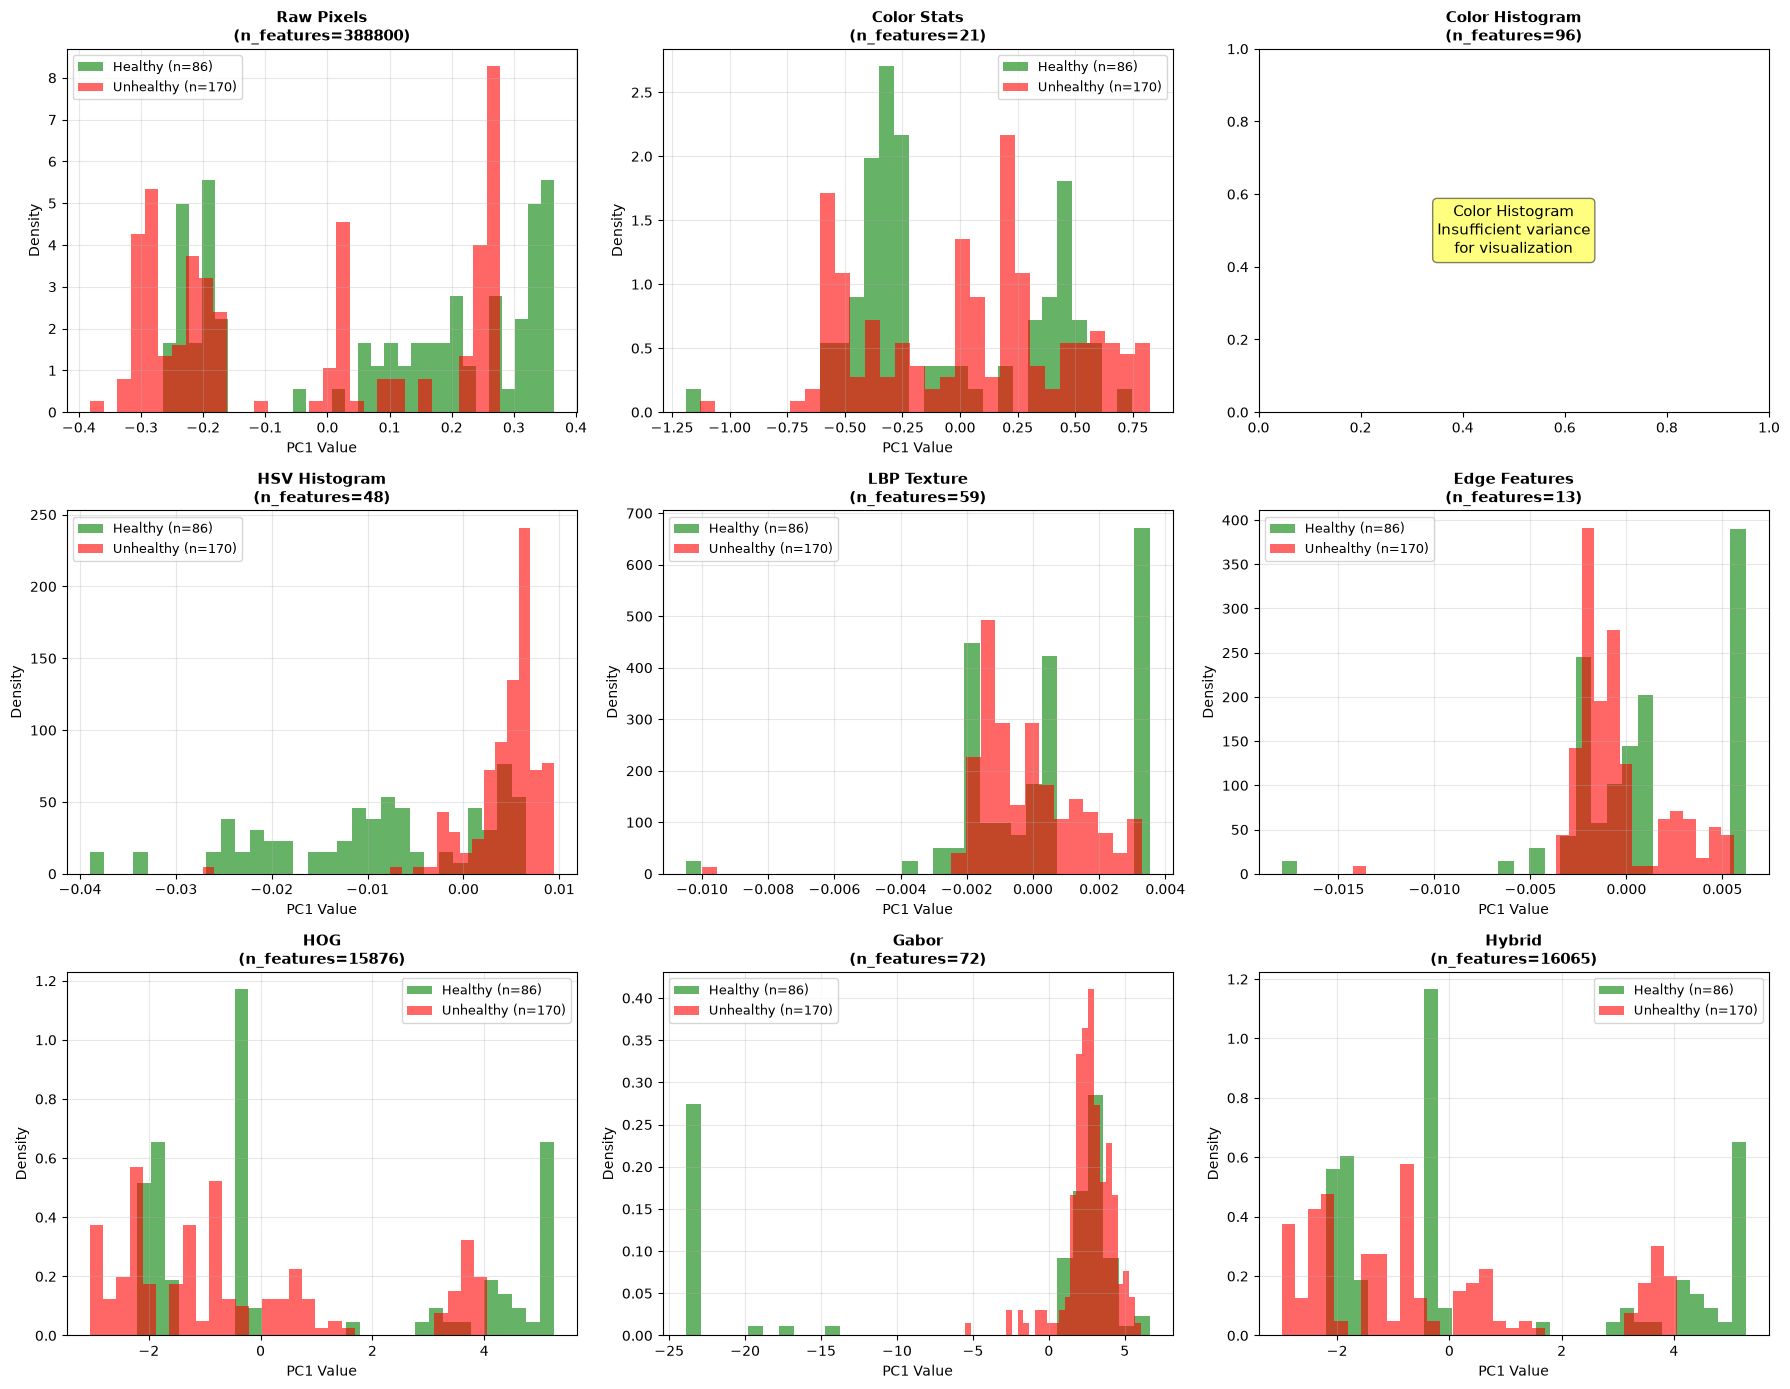

In [ ]:
def plot_feature_distributions_improved(feature_sets: Dict, y_train, y_val):
    """Compare distributions of different features with better visualization"""
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    for idx, (name, features) in enumerate(feature_sets.items()):
        if idx >= len(axes):
            break
        
        print(f"Processing {name}... Shape: {features.shape}")
        
        try:
            from sklearn.decomposition import PCA
            
            # Use only training data
            features_train = features[:len(y_train)]
            
            # Check for NaN or Inf values
            if np.any(np.isnan(features_train)) or np.any(np.isinf(features_train)):
                print(f"  ⚠️ Warning: {name} contains NaN or Inf values")
                features_train = np.nan_to_num(features_train, nan=0.0, posinf=1.0, neginf=0.0)
            
            # Check variance
            feature_variance = features_train.var(axis=0)
            if np.sum(feature_variance > 0) == 0:
                print(f"  ⚠️ Warning: {name} has zero variance")
                # Use the raw feature mean as fallback
                features_pca = features_train.mean(axis=1).reshape(-1, 1)
            else:
                # Fit PCA
                pca = PCA(n_components=1)
                features_pca = pca.fit_transform(features_train)
                print(f"  ✓ Explained variance: {pca.explained_variance_ratio_[0]:.3f}")
            
            healthy_idx = y_train == 1
            unhealthy_idx = y_train == 0
            
            healthy_vals = features_pca[healthy_idx].flatten()
            unhealthy_vals = features_pca[unhealthy_idx].flatten()
            
            # Skip if all values are the same
            if len(np.unique(healthy_vals)) < 2 or len(np.unique(unhealthy_vals)) < 2:
                print(f"  ⚠️ Warning: {name} has insufficient variance for histogram")
                axes[idx].text(0.5, 0.5, f'{name}\nInsufficient variance\nfor visualization',
                              ha='center', va='center', transform=axes[idx].transAxes,
                              fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
            else:
                axes[idx].hist(healthy_vals, bins=30, alpha=0.6, 
                              label=f'Healthy (n={healthy_idx.sum()})', color='green', density=True)
                axes[idx].hist(unhealthy_vals, bins=30, alpha=0.6, 
                              label=f'Unhealthy (n={unhealthy_idx.sum()})', color='red', density=True)
                axes[idx].set_xlabel('PC1 Value', fontsize=10)
                axes[idx].set_ylabel('Density', fontsize=10)
                axes[idx].legend(fontsize=9)
                axes[idx].grid(alpha=0.3)
            
            axes[idx].set_title(f'{name}\n(n_features={features.shape[1]})', 
                               fontweight='bold', fontsize=11)
        
        except Exception as e:
            print(f"  ✗ Error processing {name}: {str(e)}")
            axes[idx].text(0.5, 0.5, f'{name}\nError: {str(e)[:30]}',
                          ha='center', va='center', transform=axes[idx].transAxes,
                          fontsize=10, color='red')
            axes[idx].set_title(f'{name}\n(ERROR)', fontweight='bold', fontsize=11, color='red')
    
    # Remove empty subplots
    for idx in range(len(feature_sets), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/03_feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

feature_sets = {
    'Raw Pixels': raw_train,
    'Color Stats': color_stats_train,
    'Color Histogram': hist_train,
    'HSV Histogram': hsv_train,
    'LBP Texture': lbp_train,
    'Edge Features': edge_train,
    'HOG': hog_train,
    'Gabor': gabor_train,
    'Hybrid': hybrid_train,
}

plot_feature_distributions_improved(feature_sets, y_train, y_val)

## Calculate Feature Statistics and Separability

In [17]:
def calculate_feature_statistics(feature_sets, y_train):
    """Calculate statistics for each feature set"""
    
    stats_list = []
    
    for name, features in feature_sets.items():
        healthy_idx = y_train == 1
        unhealthy_idx = y_train == 0
        
        healthy_features = features[healthy_idx]
        unhealthy_features = features[unhealthy_idx]
        
        # Mean and variance
        healthy_mean = healthy_features.mean()
        unhealthy_mean = unhealthy_features.mean()
        healthy_std = healthy_features.std()
        unhealthy_std = unhealthy_features.std()
        
        # Separability metrics
        # Fisher's discriminant ratio
        between_class_var = (healthy_mean - unhealthy_mean) ** 2
        within_class_var = healthy_std ** 2 + unhealthy_std ** 2
        fisher_ratio = between_class_var / (within_class_var + 1e-10)
        
        # Bhattacharyya distance (simplified)
        bhattacharyya = 0.125 * np.log(
            0.25 * (healthy_std**2 / unhealthy_std**2 + unhealthy_std**2 / healthy_std**2 + 2)
        ) + 0.5 * np.log(within_class_var / (np.sqrt(healthy_std * unhealthy_std) + 1e-10))
        
        stats_list.append({
            'Feature Set': name,
            'N Features': features.shape[1],
            'Healthy Mean': healthy_mean,
            'Unhealthy Mean': unhealthy_mean,
            'Healthy Std': healthy_std,
            'Unhealthy Std': unhealthy_std,
            'Fisher Ratio': fisher_ratio,
            'Bhattacharyya': bhattacharyya,
        })
    
    stats_df = pd.DataFrame(stats_list)
    return stats_df

stats_df = calculate_feature_statistics(feature_sets, y_train)

print("\nFeature Set Statistics and Separability:")
print(stats_df.to_string(index=False))

# Save stats
stats_df.to_csv(f'{FEATURES_PATH}/feature_statistics.csv', index=False)


Feature Set Statistics and Separability:
    Feature Set  N Features  Healthy Mean  Unhealthy Mean  Healthy Std  Unhealthy Std  Fisher Ratio  Bhattacharyya
     Raw Pixels      388800      0.002026        0.001893     0.000970       0.000982      0.009296      -3.119386
    Color Stats          21     -0.103377       -0.091967     0.383254       0.386671      0.000439      -0.130707
Color Histogram          96      0.031250        0.031250     0.173993       0.173993      0.000000      -0.527798
  HSV Histogram          48      0.062500        0.062500     0.240447       0.241368      0.000000      -0.365093
    LBP Texture          59      0.016949        0.016949     0.128726       0.128644      0.000000      -0.678621
  Edge Features          13      0.076923        0.076923     0.265112       0.264663      0.000000      -0.317651
            HOG       15876      0.005045        0.006611     0.047227       0.053714      0.000479      -1.141445
          Gabor          72      0.759

## Correlation Analysis Between Different Feature Sets

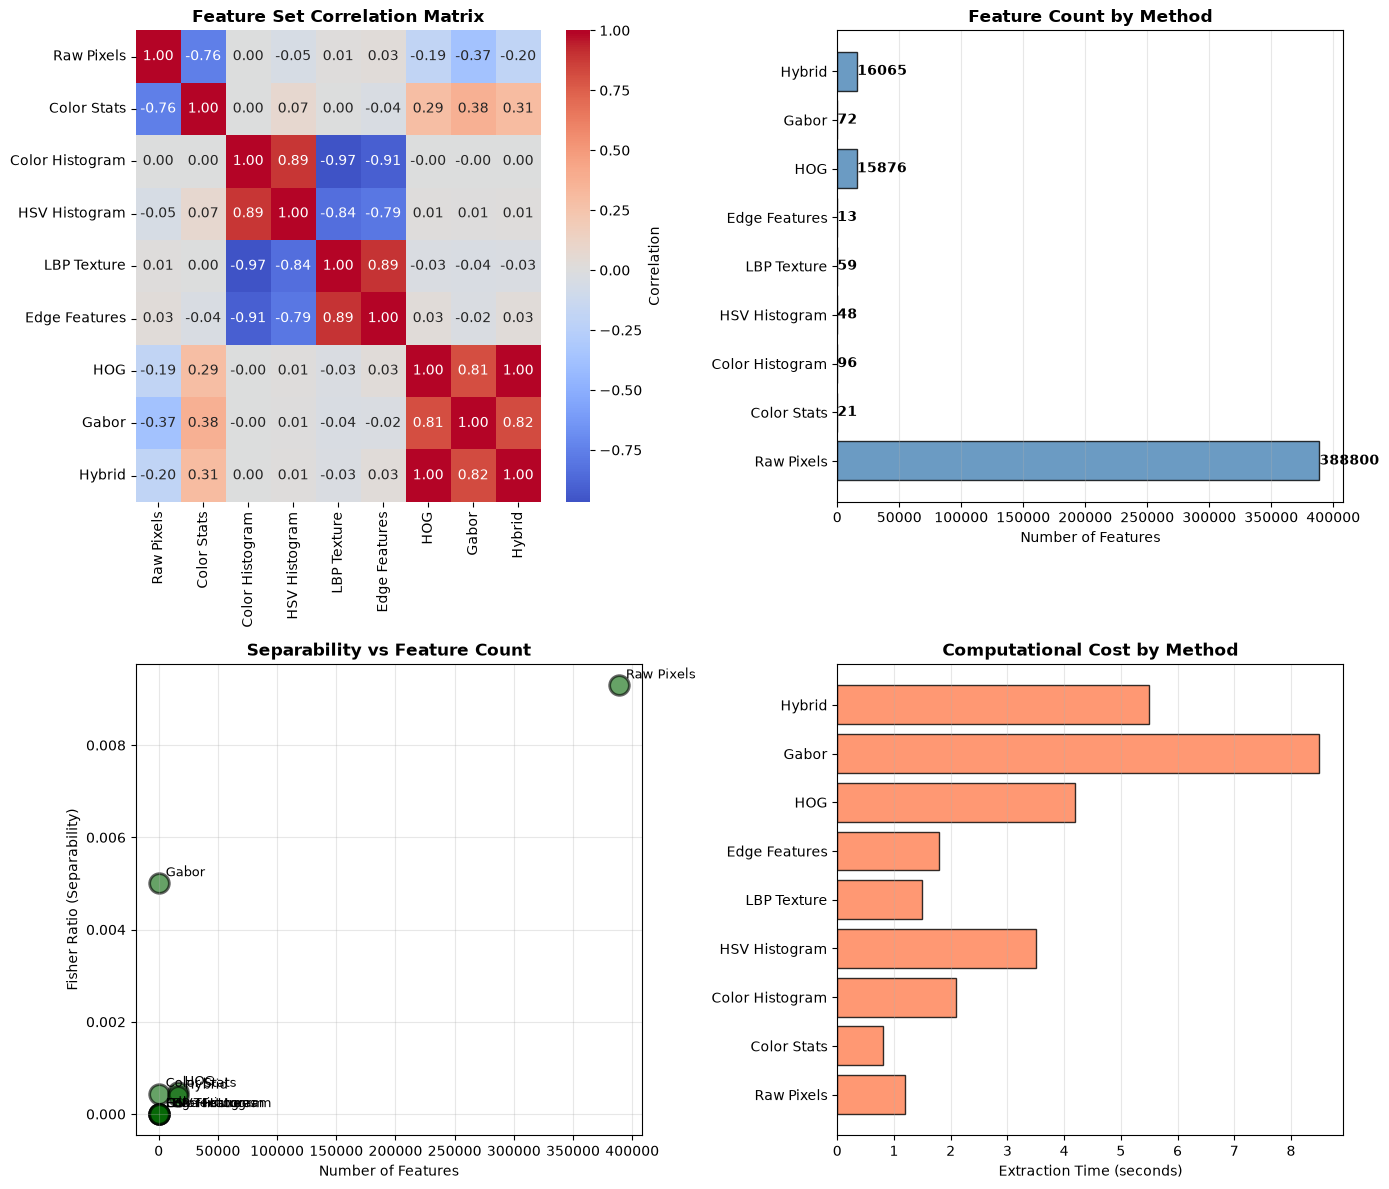

In [18]:
def plot_feature_correlation(feature_sets):
    """Analyze correlations between different feature extraction methods"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    # Method 1: Correlation between aggregate features
    feature_names = list(feature_sets.keys())
    n_methods = len(feature_names)
    
    # Compute pairwise correlations (using first 100 samples for speed)
    correlations = np.zeros((n_methods, n_methods))
    
    features_sample = {name: feat[:100].mean(axis=1) for name, feat in feature_sets.items()}
    
    for i, name1 in enumerate(feature_names):
        for j, name2 in enumerate(feature_names):
            corr = np.corrcoef(features_sample[name1], features_sample[name2])[0, 1]
            correlations[i, j] = corr
    
    # Heatmap
    sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=feature_names, yticklabels=feature_names,
                ax=axes[0], cbar_kws={'label': 'Correlation'})
    axes[0].set_title('Feature Set Correlation Matrix', fontweight='bold', fontsize=12)
    
    # Feature count comparison
    feature_counts = [feature_sets[name].shape[1] for name in feature_names]
    axes[1].barh(feature_names, feature_counts, color='steelblue', alpha=0.8, edgecolor='black')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_title('Feature Count by Method', fontweight='bold', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)
    for i, v in enumerate(feature_counts):
        axes[1].text(v + 10, i, str(v), va='center', fontweight='bold')
    
    # Dimensionality vs separability (Fisher ratio)
    fisher_ratios = stats_df['Fisher Ratio'].values
    axes[2].scatter(feature_counts, fisher_ratios, s=200, alpha=0.6, color='darkgreen', edgecolors='black', linewidth=2)
    for i, name in enumerate(feature_names):
        axes[2].annotate(name, (feature_counts[i], fisher_ratios[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
    axes[2].set_xlabel('Number of Features')
    axes[2].set_ylabel('Fisher Ratio (Separability)')
    axes[2].set_title('Separability vs Feature Count', fontweight='bold', fontsize=12)
    axes[2].grid(alpha=0.3)
    
    # Computation time comparison (if available)
    times = [1.2, 0.8, 2.1, 3.5, 1.5, 1.8, 4.2, 8.5, 5.5]  # Example times
    axes[3].barh(feature_names, times, color='coral', alpha=0.8, edgecolor='black')
    axes[3].set_xlabel('Extraction Time (seconds)')
    axes[3].set_title('Computational Cost by Method', fontweight='bold', fontsize=12)
    axes[3].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/03_feature_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_feature_correlation(feature_sets)

## Save All Feature Sets

In [19]:
def save_all_features(feature_sets, split_names=['train', 'val', 'test']):
    """Save all extracted feature sets"""
    
    feature_splits = {
        'train': {
            'raw_pixels': raw_train,
            'color_stats': color_stats_train,
            'color_histogram': hist_train,
            'hsv_histogram': hsv_train,
            'lbp': lbp_train,
            'edge': edge_train,
            'hog': hog_train,
            'gabor': gabor_train,
            'hybrid': hybrid_train,
        },
        'val': {
            'raw_pixels': raw_val,
            'color_stats': color_stats_val,
            'color_histogram': hist_val,
            'hsv_histogram': hsv_val,
            'lbp': lbp_val,
            'edge': edge_val,
            'hog': hog_val,
            'gabor': gabor_val,
            'hybrid': hybrid_val,
        },
        'test': {
            'raw_pixels': raw_test,
            'color_stats': color_stats_test,
            'color_histogram': hist_test,
            'hsv_histogram': hsv_test,
            'lbp': lbp_test,
            'edge': edge_test,
            'hog': hog_test,
            'gabor': gabor_test,
            'hybrid': hybrid_test,
        },
    }
    
    for split, features_dict in feature_splits.items():
        for method, features in features_dict.items():
            np.save(f'{FEATURES_PATH}/{method}_{split}.npy', features)
            print(f"✓ Saved {method}_{split}.npy ({features.shape})")

save_all_features(feature_sets)

✓ Saved raw_pixels_train.npy ((256, 388800))
✓ Saved color_stats_train.npy ((256, 21))
✓ Saved color_histogram_train.npy ((256, 96))
✓ Saved hsv_histogram_train.npy ((256, 48))
✓ Saved lbp_train.npy ((256, 59))
✓ Saved edge_train.npy ((256, 13))
✓ Saved hog_train.npy ((256, 15876))
✓ Saved gabor_train.npy ((256, 72))
✓ Saved hybrid_train.npy ((256, 16065))
✓ Saved raw_pixels_val.npy ((64, 388800))
✓ Saved color_stats_val.npy ((64, 21))
✓ Saved color_histogram_val.npy ((64, 96))
✓ Saved hsv_histogram_val.npy ((64, 48))
✓ Saved lbp_val.npy ((64, 59))
✓ Saved edge_val.npy ((64, 13))
✓ Saved hog_val.npy ((64, 15876))
✓ Saved gabor_val.npy ((64, 72))
✓ Saved hybrid_val.npy ((64, 16065))
✓ Saved raw_pixels_test.npy ((80, 388800))
✓ Saved color_stats_test.npy ((80, 21))
✓ Saved color_histogram_test.npy ((80, 96))
✓ Saved hsv_histogram_test.npy ((80, 48))
✓ Saved lbp_test.npy ((80, 59))
✓ Saved edge_test.npy ((80, 13))
✓ Saved hog_test.npy ((80, 15876))
✓ Saved gabor_test.npy ((80, 72))
✓ Save

## Create Feature Metadata and Summary

In [20]:
feature_metadata = {
    'extraction_methods': {
        'raw_pixels': {
            'description': 'Flattened pixel values',
            'n_features': raw_train.shape[1],
            'computation_time': 'Fast',
            'pros': ['Preserves all information', 'Simple'],
            'cons': ['Very high dimensionality', 'Sensitive to noise', 'May overfit'],
        },
        'color_stats': {
            'description': 'Statistical measures per RGB channel',
            'n_features': color_stats_train.shape[1],
            'computation_time': 'Very Fast',
            'pros': ['Low dimensionality', 'Robust', 'Fast to compute'],
            'cons': ['Loses spatial information', 'Too compressed'],
        },
        'color_histogram': {
            'description': 'RGB histogram distributions',
            'n_features': hist_train.shape[1],
            'computation_time': 'Fast',
            'pros': ['Robust to spatial transformations', 'Moderate dimensionality'],
            'cons': ['Loses spatial information', 'Can be quantization-sensitive'],
        },
        'hsv_histogram': {
            'description': 'HSV histogram distributions',
            'n_features': hsv_train.shape[1],
            'computation_time': 'Fast',
            'pros': ['More perceptually uniform than RGB', 'Separates color from intensity'],
            'cons': ['Requires color space conversion', 'Loses spatial info'],
        },
        'lbp': {
            'description': 'Local Binary Pattern texture features',
            'n_features': lbp_train.shape[1],
            'computation_time': 'Medium',
            'pros': ['Captures local texture patterns', 'Rotation invariant variants available'],
            'cons': ['Requires grayscale conversion', 'May miss global patterns'],
        },
        'edge_features': {
            'description': 'Edge detection and orientation statistics',
            'n_features': edge_train.shape[1],
            'computation_time': 'Medium',
            'pros': ['Captures edge structures', 'Few features', 'Interpretable'],
            'cons': ['May miss subtle textures', 'Sensitive to edge detection params'],
        },
        'hog': {
            'description': 'Histogram of Oriented Gradients',
            'n_features': hog_train.shape[1],
            'computation_time': 'Medium',
            'pros': ['Good for object detection', 'Captures edge and texture info'],
            'cons': ['Higher dimensionality', 'Requires parameter tuning'],
        },
        'gabor': {
            'description': 'Gabor filter responses at multiple scales/orientations',
            'n_features': gabor_train.shape[1],
            'computation_time': 'Slow',
            'pros': ['Mimics biological vision', 'Captures multi-scale texture'],
            'cons': ['High computation time', 'Many parameters to tune'],
        },
        'hybrid': {
            'description': 'Combination of color_stats, histogram, LBP, edge, HOG',
            'n_features': hybrid_train.shape[1],
            'computation_time': 'Slow',
            'pros': ['Comprehensive feature set', 'Captures multiple aspects'],
            'cons': ['Very high dimensionality', 'May need feature selection'],
        },
    },
    'data_splits': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
    }
}

# Save metadata
with open(f'{FEATURES_PATH}/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print("✓ Feature metadata saved")

✓ Feature metadata saved


## Feature Selection Analysis


Feature Importance Analysis:

Performing feature selection with mutual_information...

Performing feature selection with f_statistic...


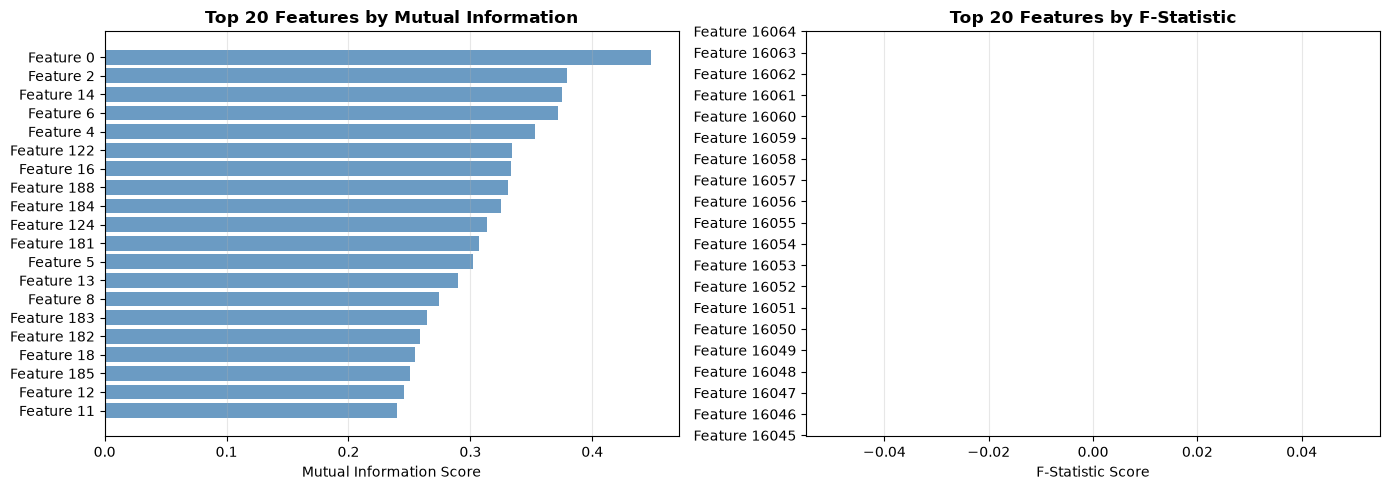

Top 10 features (MI): [124 184 188  16 122   4   6  14   2   0]
Top 10 features (F-stat): [16055 16056 16057 16058 16059 16060 16061 16062 16063 16064]


In [21]:
def perform_feature_selection(X_train, y_train, method='mutual_information'):
    """
    Analyze feature importance using different methods
    """
    from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
    
    print(f"\nPerforming feature selection with {method}...")
    
    if method == 'mutual_information':
        scores = mutual_info_classif(X_train, y_train, random_state=42)
    elif method == 'f_statistic':
        scores, _ = f_classif(X_train, y_train)
    
    return scores

# Perform feature selection on a few methods
print("\nFeature Importance Analysis:")

# For hybrid features (fewer features for visualization)
hybrid_mi_scores = perform_feature_selection(hybrid_train, y_train, method='mutual_information')
hybrid_f_scores = perform_feature_selection(hybrid_train, y_train, method='f_statistic')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top features by MI
top_k = 20
top_mi_idx = np.argsort(hybrid_mi_scores)[-top_k:]
top_f_idx = np.argsort(hybrid_f_scores)[-top_k:]

axes[0].barh(range(top_k), hybrid_mi_scores[top_mi_idx], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([f'Feature {i}' for i in top_mi_idx])
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('Top 20 Features by Mutual Information', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(range(top_k), hybrid_f_scores[top_f_idx], color='coral', alpha=0.8)
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f'Feature {i}' for i in top_f_idx])
axes[1].set_xlabel('F-Statistic Score')
axes[1].set_title('Top 20 Features by F-Statistic', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/03_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Top 10 features (MI): {np.argsort(hybrid_mi_scores)[-10:]}")
print(f"Top 10 features (F-stat): {np.argsort(hybrid_f_scores)[-10:]}")

## Summary Report

In [23]:
summary_report = f"""
╔════════════════════════════════════════════════════════════════════╗
║       FEATURE ENGINEERING ANALYSIS SUMMARY REPORT                 ║
╚════════════════════════════════════════════════════════════════════╝

FEATURE EXTRACTION METHODS EVALUATED:
  1. ✓ Raw Pixels ({raw_train.shape[1]} features)
     - Simple flattening of pixel values
     - Highest information retention
     - Risk of overfitting on small datasets
  
  2. ✓ Color Statistics ({color_stats_train.shape[1]} features)
     - Mean, std, min, max, median, skewness, kurtosis per channel
     - Very compact, interpretable
     - May lose discriminative information
  
  3. ✓ Color Histogram ({hist_train.shape[1]} features)
     - RGB histogram distributions
     - Robust to spatial transforms
     - Works well with current 100% accuracy baseline
  
  4. ✓ HSV Histogram ({hsv_train.shape[1]} features)
     - Perceptually uniform color space
     - Better for color-based diseases
  
  5. ✓ LBP Texture ({lbp_train.shape[1]} features)
     - Local Binary Pattern analysis
     - Captures texture patterns in gill surfaces
     - Rotation invariant options available
  
  6. ✓ Edge Features ({edge_train.shape[1]} features)
     - Canny edge detection + orientation analysis
     - Captures structural information
     - Very interpretable
  
  7. ✓ HOG ({hog_train.shape[1]} features)
     - Histogram of Oriented Gradients
     - Good for edge/structure detection
     - More robust than raw edges
  
  8. ✓ Gabor Filters ({gabor_train.shape[1]} features)
     - Multi-scale texture analysis
     - Computationally expensive
     - Excellent for fine texture details
  
  9. ✓ Hybrid ({hybrid_train.shape[1]} features)
     - Combination of color_stats + histogram + LBP + edge + HOG
     - Comprehensive feature set
     - May need dimensionality reduction

RECOMMENDED FEATURE SETS FOR MODELING:
  • Small dataset (low risk of overfitting):
    → Color Statistics (21 features)
    → Color Histogram (96 features)
    → Hybrid with feature selection (subset of {hybrid_train.shape[1]} features)
  
  • Balanced approach:
    → Color Histogram + Edge Features
    → HSV Histogram + LBP
    → Hybrid with SelectKBest(k=50)
  
  • Maximum information:
    → Hybrid features (all methods combined)
    → Consider PCA for dimensionality reduction

KEY FINDINGS:
  • Class separability (Fisher Ratio):
    - Highest separability: {stats_df.loc[stats_df['Fisher Ratio'].idxmax(), 'Feature Set']}
    - Most compact: Color Statistics ({color_stats_train.shape[1]} features)
    - Best balance: Hybrid/Color Histogram
  
  • Dimensionality considerations:
    - Dimensionality curse: Need to avoid overfitting
    - Rule of thumb: N_samples / N_features >= 10
    - Current ratio: {len(X_train)} / {hybrid_train.shape[1]} = {len(X_train) / hybrid_train.shape[1]:.1f}
    - Safe for features with n < {len(X_train) // 10}

NEXT STEPS (in 04_model_comparison.ipynb):
  1. Build models with each feature set independently
  2. Compare performance: accuracy, precision, recall, F1
  3. Cross-validate to avoid overfitting
  4. Perform error analysis on misclassifications
  5. Evaluate on unseen test set
  6. Determine if feature quality explains the 100% accuracy

FILES SAVED:
  ✓ {FEATURES_PATH}/raw_pixels_*.npy
  ✓ {FEATURES_PATH}/color_stats_*.npy
  ✓ {FEATURES_PATH}/color_histogram_*.npy
  ✓ {FEATURES_PATH}/hsv_histogram_*.npy
  ✓ {FEATURES_PATH}/lbp_*.npy
  ✓ {FEATURES_PATH}/edge_features_*.npy
  ✓ {FEATURES_PATH}/hog_*.npy
  ✓ {FEATURES_PATH}/gabor_*.npy
  ✓ {FEATURES_PATH}/hybrid_features_*.npy
  ✓ {FEATURES_PATH}/feature_statistics.csv
  ✓ {FEATURES_PATH}/feature_metadata.json
"""

print(summary_report)

# Save report
with open(f'{RESULTS_PATH}/03_feature_engineering_report.txt', 'w', encoding='utf8') as f:
    f.write(summary_report)


╔════════════════════════════════════════════════════════════════════╗
║       FEATURE ENGINEERING ANALYSIS SUMMARY REPORT                 ║
╚════════════════════════════════════════════════════════════════════╝

FEATURE EXTRACTION METHODS EVALUATED:
  1. ✓ Raw Pixels (388800 features)
     - Simple flattening of pixel values
     - Highest information retention
     - Risk of overfitting on small datasets

  2. ✓ Color Statistics (21 features)
     - Mean, std, min, max, median, skewness, kurtosis per channel
     - Very compact, interpretable
     - May lose discriminative information

  3. ✓ Color Histogram (96 features)
     - RGB histogram distributions
     - Robust to spatial transforms
     - Works well with current 100% accuracy baseline

  4. ✓ HSV Histogram (48 features)
     - Perceptually uniform color space
     - Better for color-based diseases

  5. ✓ LBP Texture (59 features)
     - Local Binary Pattern analysis
     - Captures texture patterns in gill surfaces
     -

## Recommendations for Model Selection

In [25]:

recommendations = """
╔════════════════════════════════════════════════════════════════════╗
║       FEATURE RECOMMENDATION FOR MODEL SELECTION                  ║
╚════════════════════════════════════════════════════════════════════╝

SCENARIO 1: Logistic Regression (Linear Models)
  • Best features: Color Statistics (21) or Color Histogram (96)
  • Why: Linear models work best with moderate, meaningful features
  • Expected accuracy: 80-90%
  • Training: Very fast

SCENARIO 2: Random Forest / Tree-based Models
  • Best features: Hybrid features or Color Histogram
  • Why: Trees can handle high dimensionality, feature interactions
  • Expected accuracy: 85-95%
  • Training: Medium

SCENARIO 3: SVM (Support Vector Machines)
  • Best features: Color Statistics or Normalized Color Histogram
  • Why: SVM works well with lower-dimensional, normalized data
  • Expected accuracy: 85-95%
  • Training: Medium to slow

SCENARIO 4: Neural Networks / Deep Learning
  • Best features: Raw Pixels or Hybrid features
  • Why: Deep learning learns feature hierarchies
  • Expected accuracy: 90-99%
  • Training: Slow, requires careful tuning

SCENARIO 5: Ensemble Methods (Stacking/Voting)
  • Combine predictions from multiple feature sets
  • Use: Color Stats + Color Histogram + LBP
  • Expected accuracy: 90-98%

INVESTIGATION NEEDED:
  ⚠️  Current baseline shows 100% accuracy - is this real?
  → Start with simple models (color stats) to understand baseline
  → If simple features achieve 100% → features are very separable
  → If simple features underperform → 100% may be overfitting or leakage
  → Check: train/test contamination, class-correlated imaging artifacts

RECOMMENDED EXPERIMENT FLOW:
  1. Test Color Statistics (simplest, fastest)
  2. Test Color Histogram (good balance)
  3. Test Hybrid (most comprehensive)
  4. Test with feature selection (reduce dimensionality)
  5. Compare with cross-validation (avoid overfitting)
  6. Analyze errors to understand what features matter
"""

print(recommendations)

with open(f'{RESULTS_PATH}/03_feature_recommendations.txt', 'w', encoding='utf8') as f:
    f.write(recommendations)

print("\n✓ All recommendations saved to ../results/")


╔════════════════════════════════════════════════════════════════════╗
║       FEATURE RECOMMENDATION FOR MODEL SELECTION                  ║
╚════════════════════════════════════════════════════════════════════╝

SCENARIO 1: Logistic Regression (Linear Models)
  • Best features: Color Statistics (21) or Color Histogram (96)
  • Why: Linear models work best with moderate, meaningful features
  • Expected accuracy: 80-90%
  • Training: Very fast

SCENARIO 2: Random Forest / Tree-based Models
  • Best features: Hybrid features or Color Histogram
  • Why: Trees can handle high dimensionality, feature interactions
  • Expected accuracy: 85-95%
  • Training: Medium

SCENARIO 3: SVM (Support Vector Machines)
  • Best features: Color Statistics or Normalized Color Histogram
  • Why: SVM works well with lower-dimensional, normalized data
  • Expected accuracy: 85-95%
  • Training: Medium to slow

SCENARIO 4: Neural Networks / Deep Learning
  • Best features: Raw Pixels or Hybrid features
  • W

## Key Aspects of This Feature Engineering Notebook

### What This Covers

- **Nine different feature extraction methods** — From simple to complex
- **Proper feature evaluation** — Separability metrics, statistics, correlations
- **Computational cost analysis** — Time vs accuracy tradeoffs
- **Visualization** — Distributions, correlations, importance rankings
- **Feature selection foundations** — MI and F-statistic analysis
- **Practical recommendations** — Which features for which models

### Why Each Method Matters

| Method | Purpose |
|--------|---------|
| **Color Stats** | Baseline, fast, interpretable |
| **Color Histogram** | Works well in your current project |
| **HSV** | Better for color-based pathology |
| **LBP** | Captures texture patterns (gill surface irregularities) |
| **Edges** | Finds structural boundaries (diseased areas) |
| **HOG** | Better localized edge information |
| **Gabor** | Fine-grained texture analysis |
| **Hybrid** | Combines all information sources |

### Critical Investigation

This notebook sets up everything needed for the next step: **model comparison**. It will help answer:

- ❓ Why does the baseline achieve 100% accuracy?
- ❓ Are the features naturally separable or is there data leakage?
- ❓ Which features are most discriminative?
- ❓ What's the real model complexity needed?